# 7일 무료 체험 행동 기반 최종 전환 분석 (Aha Moment 찾기)

이 노트북은 가입 후 초기 7일간의 유저 행동 데이터를 상세히 분석하여, 최종적으로 유료 결제에 이르는 핵심 행동(Aha Moment)을 탐색합니다.

In [1]:
!pip install koreanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import timedelta
import os
import koreanize_matplotlib


import warnings
warnings.filterwarnings('ignore')

## 1. 데이터 로드 및 전처리

In [3]:
df_funnel = pd.read_csv('../data/join.csv')
df_payment = pd.read_csv('../data/payment_transactions.csv')

df_funnel['event_timestamp'] = pd.to_datetime(df_funnel['event_timestamp'], format='mixed', errors='coerce')
df_payment['transaction_date'] = pd.to_datetime(df_payment['transaction_date'], format='mixed', errors='coerce')

# 유효하지 않은 날짜(NaT) 제거
df_funnel = df_funnel.dropna(subset=['event_timestamp'])
df_payment = df_payment.dropna(subset=['transaction_date'])

print(f"이벤트 로그 수: {len(df_funnel)}")
print(f"결제 데이터 수: {len(df_payment)}")

이벤트 로그 수: 747341
결제 데이터 수: 8177


In [4]:
# 1. 각 유저별 가입 완료(signup_completed) 시점 찾기
df_signup = df_funnel[df_funnel['event_name'] == 'signup_completed'].sort_values('event_timestamp').groupby('user_id').first().reset_index()
df_signup = df_signup[['user_id', 'event_timestamp']].rename(columns={'event_timestamp': 'signup_time'})

# 2. 원본 데이터에 가입 시점 병합
df_merged = pd.merge(df_funnel, df_signup, on='user_id', how='inner')

# 3. 가입 시점으로부터 7일(168시간) 이내의 행동 이벤트만 필터링
df_7d_behavior = df_merged[(df_merged['event_timestamp'] >= df_merged['signup_time']) & 
                           (df_merged['event_timestamp'] <= df_merged['signup_time'] + timedelta(days=7))]

print(f"초기 7일 이내 행동 이벤트 수: {len(df_7d_behavior)}")
print(f"분석 대상 유저 수: {df_7d_behavior['user_id'].nunique()}")

초기 7일 이내 행동 이벤트 수: 277412
분석 대상 유저 수: 14050


### 최종 전환 유저 식별 (가입 후 모든 기간 적용)

In [5]:
# 1. 성공적인 결제 이력이 있는 모든 유저 추출
final_converted_users = df_payment[df_payment['status'] == 'completed']['user_id'].unique()

# 2. 분석 대상 유저 베이스 생성 (초기 7일 행동이 있는 유저 중 최종 결제 여부 확인)
user_base = df_7d_behavior[['user_id']].drop_duplicates()
user_base['converted'] = user_base['user_id'].isin(final_converted_users)

print(f"최종 전환 유저: {user_base['converted'].sum()}명")
print(f"전체 최종 전환율: {user_base['converted'].mean()*100:.2f}%")

최종 전환 유저: 3920명
전체 최종 전환율: 27.90%


## Task 2. 상세 행동 지표 비교 (가입 초기 7일 기준)

In [6]:
def extract_quiz_info(props):
    try:
        p = json.loads(props)
        return pd.Series([1, int(p.get('is_correct', 0))])
    except:
        return pd.Series([0, 0])

# 퀴즈 정답 수 추출
df_quiz = df_7d_behavior[df_7d_behavior['event_name'] == 'quiz_submitted'].copy()
df_quiz[['quiz_count', 'quiz_correct']] = df_quiz['event_properties'].apply(extract_quiz_info)

user_quiz = df_quiz.groupby('user_id').agg(
    quiz_submitted=('quiz_count', 'sum'),
    quiz_correct_count=('quiz_correct', 'sum')
).reset_index()

# 수강 시간 계산 (세션 시작 ~ 종료 시간 차이 합계)
df_session = df_7d_behavior[df_7d_behavior['event_name'].isin(['session_started', 'session_ended'])].sort_values(['user_id', 'event_timestamp'])
df_session['next_timestamp'] = df_session.groupby('user_id')['event_timestamp'].shift(-1)
df_session['next_event'] = df_session.groupby('user_id')['event_name'].shift(-1)

df_valid_session = df_session[(df_session['event_name'] == 'session_started') & (df_session['next_event'] == 'session_ended')].copy()
df_valid_session['duration'] = (df_valid_session['next_timestamp'] - df_valid_session['event_timestamp']).dt.total_seconds() / 60 # 분 단위

user_study_time = df_valid_session.groupby('user_id')['duration'].sum().reset_index().rename(columns={'duration': 'total_study_minutes'})

# 기타 행동 지표 집계
user_other_metrics = df_7d_behavior.groupby('user_id').agg(
    lesson_started=('event_name', lambda x: (x == 'lesson_started').sum()),
    lesson_completed=('event_name', lambda x: (x == 'lesson_completed').sum()),
    course_completed=('event_name', lambda x: (x == 'course_completed').sum()),
    certificate_downloaded=('event_name', lambda x: (x == 'certificate_downloaded').sum()),
    active_days=('event_timestamp', lambda x: x.dt.date.nunique()),
    onboarding_done=('event_name', lambda x: (x == 'onboarding_completed').any().astype(int))
).reset_index()

# 모든 지표 병합
user_behavior = pd.merge(user_other_metrics, user_quiz, on='user_id', how='left').fillna(0)
user_behavior = pd.merge(user_behavior, user_study_time, on='user_id', how='left').fillna(0)
user_behavior = pd.merge(user_behavior, user_base, on='user_id')

# 그룹별 평균 비교
cols_to_compare = [
    'lesson_started', 'lesson_completed', 'course_completed', 
    'quiz_submitted', 'quiz_correct_count', 'certificate_downloaded', 
    'total_study_minutes', 'active_days', 'onboarding_done'
]
comparison = user_behavior.groupby('converted')[cols_to_compare].mean()
print("--- 최종 전환 여부에 따른 초기 7일간의 평균 행동 지표 ---")
display(comparison)

--- 최종 전환 여부에 따른 초기 7일간의 평균 행동 지표 ---


,lesson_started,lesson_completed,course_completed,quiz_submitted,quiz_correct_count,certificate_downloaded,total_study_minutes,active_days,onboarding_done
converted,,,,,,,,,
False,1.438894,1.269497,0.0,0.141362,0.072261,0.0,16.286183,2.712636,0.578184
True,1.938776,1.744388,0.0,0.272449,0.190816,0.0,20.589133,3.048469,0.637245


### 횟수별 전환율 상세 분석 (Task 2-2)

1. 레슨 완료 수별 전환율


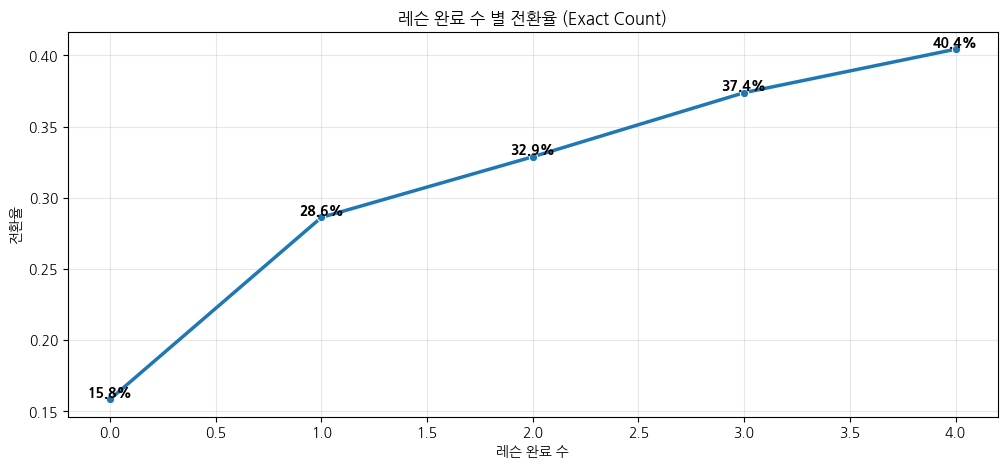

2. 활성 일수별 전환율


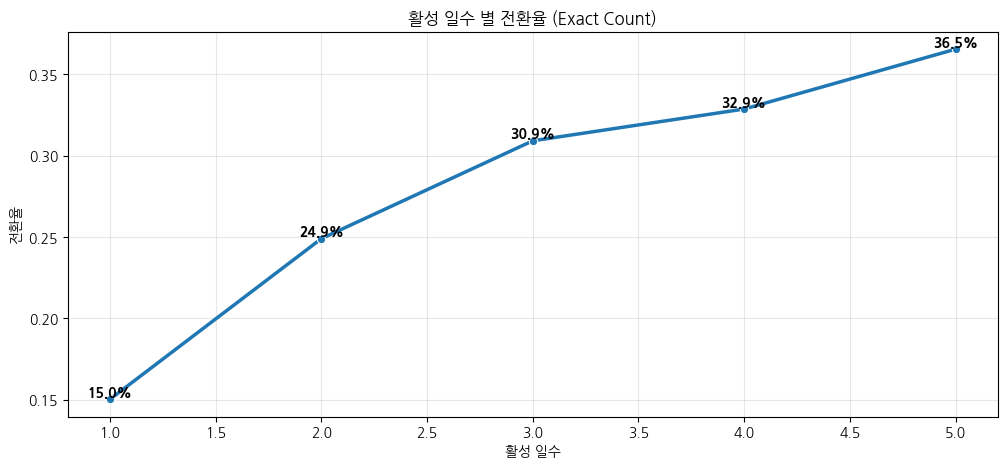

In [7]:
def plot_conversion_line_chart(df, column, title):
    # 횟수별 '딱 그 횟수만큼' 행동한 유저의 전환율 (꺽은선 그래프)
    max_val = int(df[column].quantile(0.95)) if df[column].nunique() > 1 else 1
    
    res = []
    for i in range(max_val + 1):
        subset = df[df[column] == i]
        if len(subset) > 0:
            cr = subset['converted'].mean()
            res.append({'횟수': i, '전환율': cr, '유저수': len(subset)})
    
    res_df = pd.DataFrame(res)
    
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=res_df, x='횟수', y='전환율', marker='o', linewidth=2.5, color='#1f77b4')
    plt.title(f'{title} 별 전환율 (Exact Count)')
    plt.ylabel('전환율')
    plt.xlabel(f'{title}')
    
    for idx, row in res_df.iterrows():
        plt.text(row['횟수'], row['전환율'], f"{row['전환율']*100:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.grid(True, alpha=0.3)
    plt.show()
    return res_df

print("1. 레슨 완료 수별 전환율")
lesson_cr_table = plot_conversion_line_chart(user_behavior, 'lesson_completed', '레슨 완료 수')

print("2. 활성 일수별 전환율")
active_cr_table = plot_conversion_line_chart(user_behavior, 'active_days', '활성 일수')

## Task 3. Aha Moment 탐색 (누적 기준)

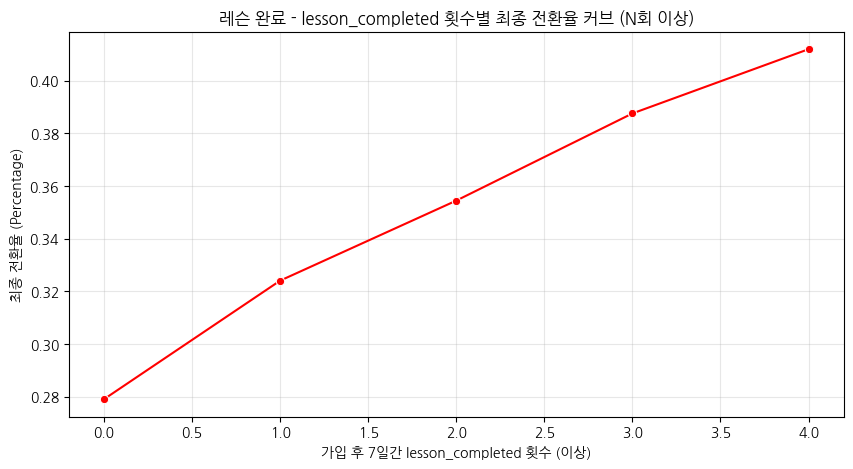

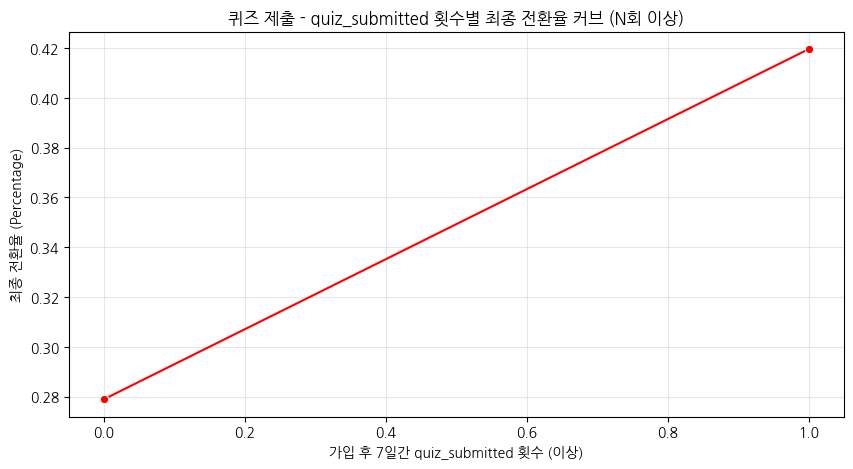

In [8]:
def plot_conversion_curve_cumulative(df, column, title):
    # 특정 횟수 이상의 전환율 계산
    max_val = int(df[column].quantile(0.95)) if df[column].nunique() > 1 else 1
    
    res = []
    for i in range(max_val + 1):
        subset = df[df[column] >= i]
        if len(subset) > 0:
            cr = subset['converted'].mean()
            res.append({'count': i, 'cr': cr, 'user_count': len(subset)})
    
    res_df = pd.DataFrame(res)
    if res_df.empty: return res_df
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=res_df, x='count', y='cr', marker='o', color='red')
    plt.title(f'{title} - {column} 횟수별 최종 전환율 커브 (N회 이상)')
    plt.ylabel('최종 전환율 (Percentage)')
    plt.xlabel(f'가입 후 7일간 {column} 횟수 (이상)')
    plt.grid(True, alpha=0.3)
    plt.show()
    return res_df

lesson_cr = plot_conversion_curve_cumulative(user_behavior, 'lesson_completed', '레슨 완료')
quiz_cr = plot_conversion_curve_cumulative(user_behavior, 'quiz_submitted', '퀴즈 제출')

### 1) 데이터 로드

In [9]:
df_join = pd.read_csv("../data/join.csv")
df_pay = pd.read_csv("../data/payment_transactions.csv")

df_join["event_timestamp"] = pd.to_datetime(df_join["event_timestamp"], errors="coerce")
df_join = df_join.dropna(subset=["user_id", "event_name", "event_timestamp"])

### 2) 가입시점(T0)과 7일 행동 구간 생성

In [10]:
signup = (
    df_join[df_join["event_name"] == "signup_completed"][["user_id", "event_timestamp"]]
    .sort_values(["user_id", "event_timestamp"])
    .groupby("user_id", as_index=False)
    .first()
    .rename(columns={"event_timestamp": "signup_time"})
)
signup

,user_id,signup_time
0,U-05001,2025-01-06 15:47:10
1,U-05002,2025-01-06 19:54:39
2,U-05003,2025-01-06 20:04:59
3,U-05004,2025-01-06 13:16:24
4,U-05005,2025-01-06 19:51:09
...,...,...
14045,U-19046,2025-05-25 22:45:24
14046,U-19047,2025-05-25 22:12:14
14047,U-19048,2025-05-25 20:00:06
14048,U-19049,2025-05-25 13:07:30


In [11]:
df_merged = df_join.merge(signup, on="user_id", how="inner")
df_7d = df_merged[
    (df_merged["event_timestamp"] >= df_merged["signup_time"]) &
    (df_merged["event_timestamp"] < df_merged["signup_time"] + pd.Timedelta(days=7))
].copy()
df_7d.head()

,user_id,session_id,event_name,event_timestamp,device_type,location,event_sequence,page_name,course_id,lesson_id,event_properties,signup_time
1,U-05023,S-5e3be906fdea,signup_completed,2025-01-06 08:24:51,ios,South Korea,2.0,NaN,NaN,NaN,"{""signup_method"": ""kakao"", ""acquisition_source...",2025-01-06 08:24:51
2,U-05023,S-5e3be906fdea,onboarding_started,2025-01-06 08:26:23,ios,South Korea,3.0,NaN,NaN,NaN,NaN,2025-01-06 08:24:51
3,U-05023,S-5e3be906fdea,onboarding_step_completed,2025-01-06 08:29:21,ios,South Korea,4.0,NaN,NaN,NaN,"{""step"": 1}",2025-01-06 08:24:51
4,U-05023,S-5e3be906fdea,session_ended,2025-01-06 08:30:34,ios,South Korea,5.0,NaN,NaN,NaN,NaN,2025-01-06 08:24:51
6,U-05018,S-cdf0cc5e4724,signup_completed,2025-01-06 08:50:33,ios,South Korea,2.0,NaN,NaN,NaN,"{""signup_method"": ""email"", ""acquisition_source...",2025-01-06 08:50:33


### 3) 전환 라벨 생성

In [12]:
converted_users = set(df_pay.loc[df_pay["status"] == "completed", "user_id"].unique())
user_base = signup[["user_id"]].copy()
user_base["converted"] = user_base["user_id"].isin(converted_users).astype(int)
user_base['converted'].value_counts()

converted
0    10130
1     3920
Name: count, dtype: int64

### 4) 행동별 횟수 피처 생성 (원하는 이벤트만 넣어서 사용)

In [13]:
def extract_quiz_correct(props):
    # event_properties에서 is_correct 추출 (없으면 0)
    try:
        if pd.isna(props):
            return 0
        p = json.loads(props) if isinstance(props, str) else props
        return int(p.get("is_correct", 0))
    except:
        return 0

In [14]:
# 4-1) quiz
df_quiz = df_7d_behavior[df_7d_behavior["event_name"] == "quiz_submitted"].copy()

if len(df_quiz) > 0:
    df_quiz["quiz_correct"] = df_quiz["event_properties"].apply(extract_quiz_correct)

    user_quiz = (
        df_quiz.groupby("user_id", as_index=False)
        .agg(
            quiz_submitted=("event_name", "count"),
            quiz_correct_count=("quiz_correct", "sum")
        )
    )
else:
    user_quiz = pd.DataFrame(columns=["user_id", "quiz_submitted", "quiz_correct_count"])

display(user_quiz.head())

,user_id,quiz_submitted,quiz_correct_count
0,U-05006,1,0
1,U-05011,1,1
2,U-05014,1,1
3,U-05017,1,1
4,U-05018,1,1


In [15]:
# 4-2) total_study_minutes (session_started -> session_ended 페어)
df_session = df_7d_behavior[
    df_7d_behavior["event_name"].isin(["session_started", "session_ended"])
].sort_values(["user_id", "event_timestamp"]).copy()

df_session["next_event"] = df_session.groupby("user_id")["event_name"].shift(-1)
df_session["next_ts"] = df_session.groupby("user_id")["event_timestamp"].shift(-1)

df_valid = df_session[
    (df_session["event_name"] == "session_started") &
    (df_session["next_event"] == "session_ended")
].copy()

df_valid["duration_min"] = (
    (df_valid["next_ts"] - df_valid["event_timestamp"]).dt.total_seconds() / 60
)

In [16]:
df_valid = df_valid[(df_valid["duration_min"] >= 0) & (df_valid["duration_min"] <= 360)]

In [17]:
user_study = (
    df_valid.groupby("user_id", as_index=False)
    .agg(total_study_minutes=("duration_min", "sum"))
    if len(df_valid) > 0
    else pd.DataFrame(columns=["user_id", "total_study_minutes"])
)
user_study.head()

,user_id,total_study_minutes
0,U-05001,16.316667
1,U-05002,8.683333
2,U-05003,7.000000
3,U-05004,21.433333
4,U-05005,28.250000


In [18]:
# 4-3) 나머지 행동 지표
user_other = (
    df_7d_behavior.groupby("user_id", as_index=False)
    .agg(
        lesson_started=("event_name", lambda x: (x == "lesson_started").sum()),
        lesson_completed=("event_name", lambda x: (x == "lesson_completed").sum()),
        course_completed=("event_name", lambda x: (x == "course_completed").sum()),
        certificate_download=("event_name", lambda x: (x == "certificate_downloaded").sum()),  # 요청 변수명에 맞춤
        active_days=("event_timestamp", lambda x: x.dt.date.nunique()),
        onboarding_done=("event_name", lambda x: int((x == "onboarding_completed").any()))
    )
)
user_other.head()

,user_id,lesson_started,lesson_completed,course_completed,certificate_download,active_days,onboarding_done
0,U-05001,1,1,0,0,3,0
1,U-05002,2,2,0,0,1,1
2,U-05003,1,2,0,0,2,0
3,U-05004,4,3,0,0,3,1
4,U-05005,3,2,0,0,3,1


In [19]:
# 4-4) 병합 (user_base: user_id, converted 가 이미 존재한다고 가정)
user_behavior = user_base[["user_id", "converted"]].copy()
user_behavior = user_behavior.merge(user_other, on="user_id", how="left")
user_behavior = user_behavior.merge(user_quiz, on="user_id", how="left")
user_behavior = user_behavior.merge(user_study, on="user_id", how="left")
user_behavior = user_behavior.fillna(0)

In [20]:
int_cols = [
    "converted",
    "lesson_started",
    "lesson_completed",
    "quiz_submitted",
    "quiz_correct_count",
    "certificate_download",
    "course_completed",
    "active_days",
    "onboarding_done",
]
for c in int_cols:
    user_behavior[c] = user_behavior[c].astype(int)
    
user_behavior["total_study_minutes"] = user_behavior["total_study_minutes"].astype(float)


In [21]:
user_behavior = user_behavior[
    [
        "user_id", "converted",
        "lesson_started", "lesson_completed", "quiz_submitted",
        "quiz_correct_count", "certificate_download",
        "course_completed", "total_study_minutes",
        "active_days", "onboarding_done"
    ]
]

display(user_behavior.head())

,user_id,converted,lesson_started,lesson_completed,quiz_submitted,quiz_correct_count,certificate_download,course_completed,total_study_minutes,active_days,onboarding_done
0,U-05001,1,1,1,0,0,0,0,16.316667,3,0
1,U-05002,1,2,2,0,0,0,0,8.683333,1,1
2,U-05003,1,1,2,0,0,0,0,7.000000,2,0
3,U-05004,0,4,3,0,0,0,0,21.433333,3,1
4,U-05005,1,3,2,0,0,0,0,28.250000,3,1


### 5) 각 행동별 전환율 테이블

In [22]:
metrics = [
    "lesson_started",
    "lesson_completed",
    "quiz_correct_count",
    "certificate_download",
    "course_completed",
    "total_study_minutes",
    "active_days",
    "onboarding_done",
    "quiz_submitted"
]

In [23]:
def conversion_table_by_metric(df, metric, min_users=30, q=0.95):
    d = df.copy()

    # total_study_minutes는 연속형이라 구간(bin)으로 전환
    if metric == "total_study_minutes":
        bins = [0, 1, 5, 10, 20, 30, 60, 120, 300, float("inf")]
        labels = ["0-1", "1-5", "5-10", "10-20", "20-30", "30-60", "60-120", "120-300", "300+"]
        d["bucket"] = pd.cut(d[metric], bins=bins, labels=labels, include_lowest=True)
        grp_col = "bucket"
    else:
        # 횟수형은 상위 극단값 컷(95%)
        max_v = int(d[metric].quantile(q)) if d[metric].nunique() > 1 else int(d[metric].max())
        d = d[d[metric] <= max_v].copy()
        grp_col = metric

    t = (
        d.groupby(grp_col, dropna=False, as_index=False)
         .agg(
             users=("user_id", "count"),
             converted_users=("converted", "sum")
         )
    )
    t["conversion_rate"] = t["converted_users"] / t["users"]
    t = t[t["users"] >= min_users].copy()

    t["metric"] = metric
    t = t.rename(columns={grp_col: "level"})
    return t[["metric", "level", "users", "converted_users", "conversion_rate"]]

In [24]:
tables = [conversion_table_by_metric(user_behavior, m, min_users=30, q=0.95) for m in metrics]
conversion_table = pd.concat(tables, ignore_index=True)

In [25]:
conversion_table = conversion_table.sort_values(["metric", "level"]).reset_index(drop=True)

display(conversion_table)

,metric,level,users,converted_users,conversion_rate
0,active_days,1,1824,274,0.150219
1,active_days,2,4153,1034,0.248977
2,active_days,3,4380,1354,0.309132
3,active_days,4,2568,844,0.328660
4,active_days,5,892,326,0.365471
5,certificate_download,0,14050,3920,0.279004
6,course_completed,0,14050,3920,0.279004
7,lesson_completed,0,3816,604,0.158281
8,lesson_completed,1,4554,1303,0.286122
9,lesson_completed,2,3200,1052,0.328750


### 행동별 전환율 커브

In [26]:
from matplotlib.collections import LineCollection

In [27]:
plt.style.use("default")
plt.rcParams["axes.grid"] = False

def make_curve(df, metric, mode="exact", min_users=30, q=0.95, time_bins=None):
    d = df.copy()

    # 1) 시간 변수는 binning
    if metric == "total_study_minutes":
        if time_bins is None:
            time_bins = [0, 5, 10, 20, 30, 45, 60, 90, 120, 180, np.inf]
        labels = [f"{int(time_bins[i])}-{int(time_bins[i+1])}" if np.isfinite(time_bins[i+1]) else f"{int(time_bins[i])}+"
                  for i in range(len(time_bins)-1)]
        d["level"] = pd.cut(d[metric], bins=time_bins, labels=labels, include_lowest=True, right=False)
        t = (d.groupby("level", observed=True)
               .agg(users=("user_id","count"), converted_users=("converted","sum"))
               .reset_index())
        t = t[t["users"] >= min_users].copy()
        t["conversion_rate"] = t["converted_users"] / t["users"]
        return t.rename(columns={"level":"x"}), "categorical"

    # 2) 횟수 변수
    s = pd.to_numeric(d[metric], errors="coerce").fillna(0)
    max_n = int(s.quantile(q)) if s.nunique() > 1 else int(s.max())
    max_n = max(max_n, 1)

    rows = []
    for n in range(max_n + 1):
        sub = d[s == n] if mode == "exact" else d[s >= n]
        if len(sub) >= min_users:
            rows.append({"x": n, "users": len(sub), "converted_users": int(sub["converted"].sum()),
                         "conversion_rate": sub["converted"].mean()})

    t = pd.DataFrame(rows)
    return t, "numeric"

def plot_conversion(df, metric, mode="exact", min_users=30, q=0.95, steep_q=0.8, min_jump=0.03):
    curve, kind = make_curve(df, metric, mode=mode, min_users=min_users, q=q)

    if curve.empty:
        print(f"[SKIP] {metric}: 표시할 데이터 부족")
        return curve

    # 2개 레벨이면 bar chart
    use_bar = curve["x"].nunique() <= 2 or kind == "categorical"

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.grid(False)

    if use_bar:
        x_labels = curve["x"].astype(str).tolist()
        y = curve["conversion_rate"].values
        bars = ax.bar(x_labels, y, color="#1f77b4", width=0.6)

        if len(y) >= 2:
            # 급격 차이 강조: 최대/최소 막대 강조
            idx_max, idx_min = int(np.argmax(y)), int(np.argmin(y))
            bars[idx_max].set_color("#e53935")
            if idx_min != idx_max:
                bars[idx_min].set_color("#ff8a80")

        for i, v in enumerate(y):
            ax.text(i, v + 0.008, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9)

        ax.set_xlabel("count")
        ax.set_ylabel("conversion_rate")
        ax.set_title(f"{metric} Conversion")

    else:
        x = curve["x"].to_numpy()
        y = curve["conversion_rate"].to_numpy()

        # 기본 선/점
        ax.plot(x, y, marker="o", color="#1f77b4", linewidth=2.5)

        # 급격 구간 강조
        dy = np.abs(np.diff(y))
        if len(dy) > 0:
            th = max(np.quantile(dy, steep_q), min_jump)
            for i, dlt in enumerate(dy):
                if dlt >= th:
                    ax.plot([x[i], x[i+1]], [y[i], y[i+1]], color="#e53935", linewidth=3.2)

        for xi, yi in zip(x, y):
            ax.text(xi, yi + 0.008, f"{yi*100:.1f}%", ha="center", va="bottom", fontsize=9)

        ax.set_xlabel("behavior_count")
        ax.set_ylabel("retention_rate")
        ax.set_title(f"{metric} Conversion Curve")

    ax.set_ylim(0, min(1.0, curve["conversion_rate"].max() + 0.08))
    plt.show()
    return curve


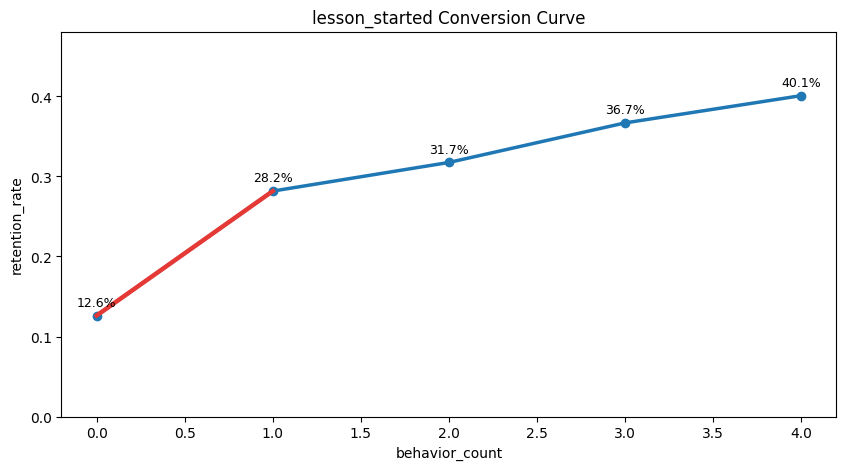

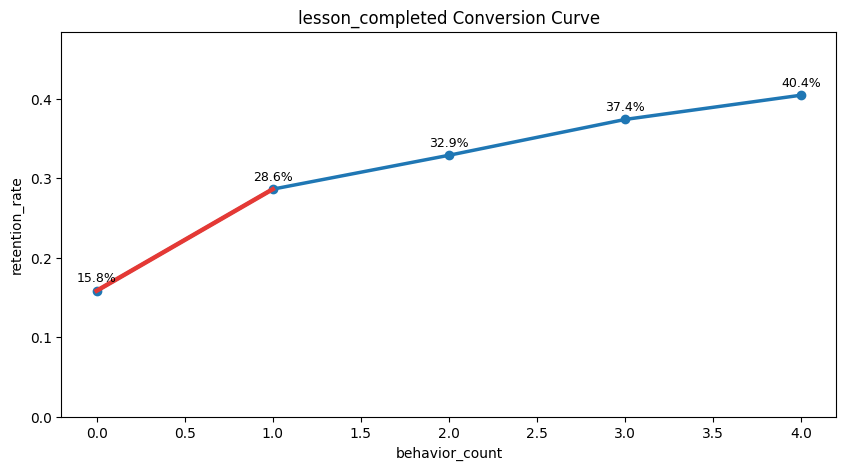

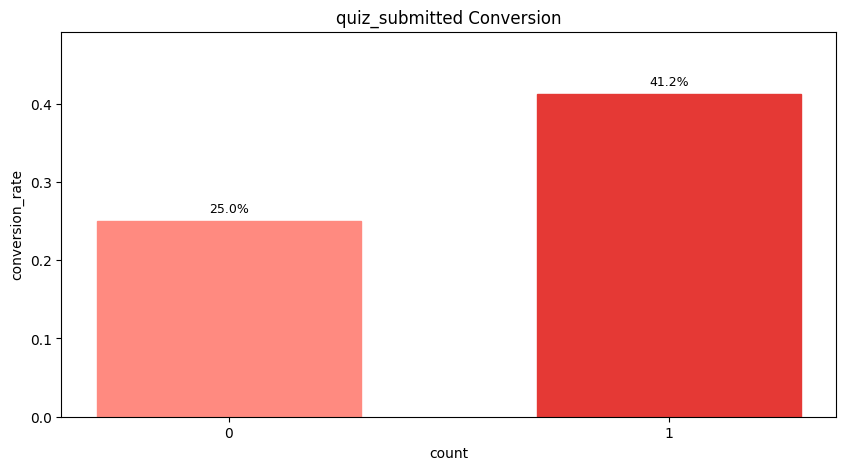

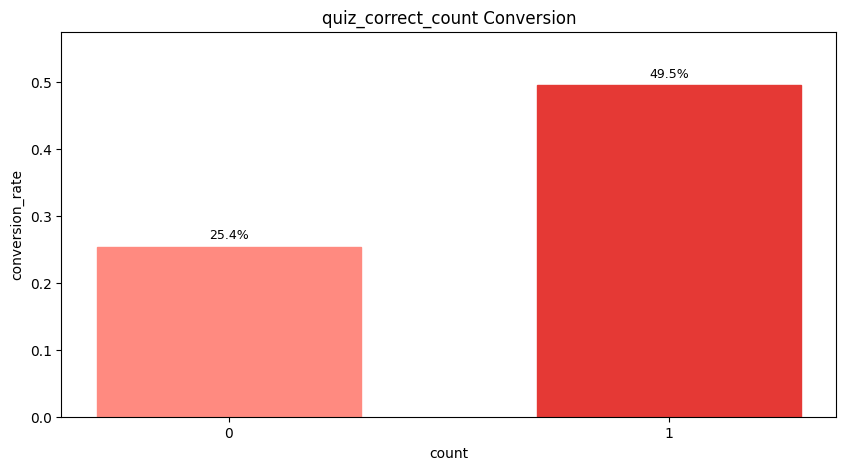

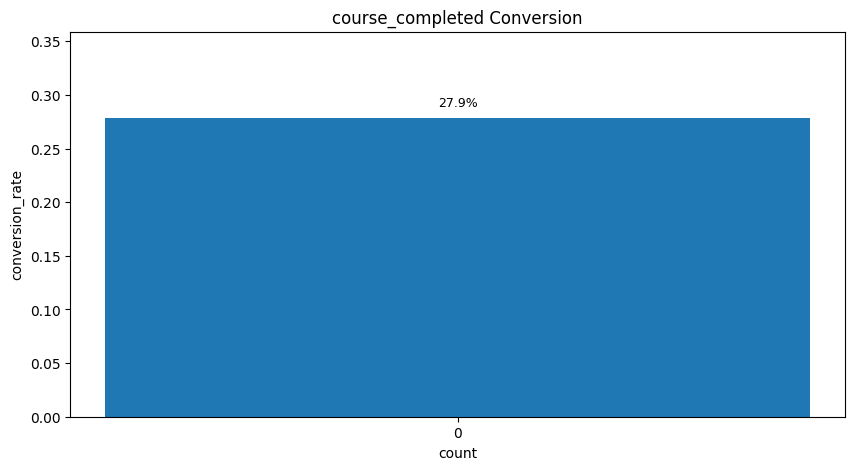

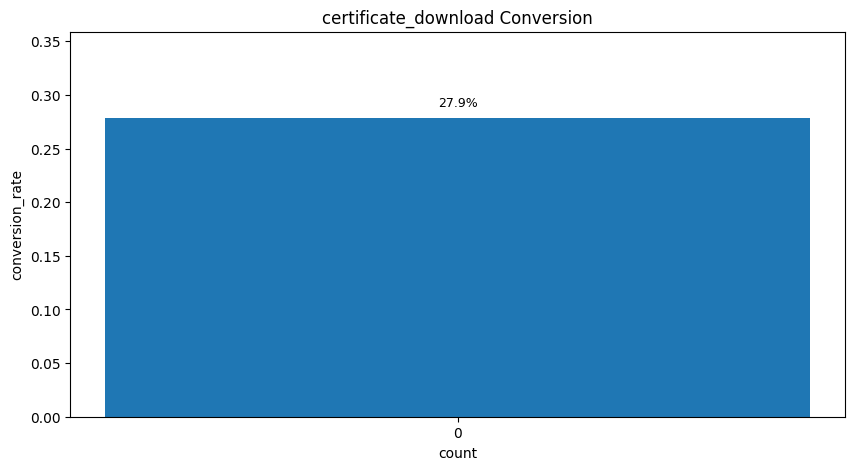

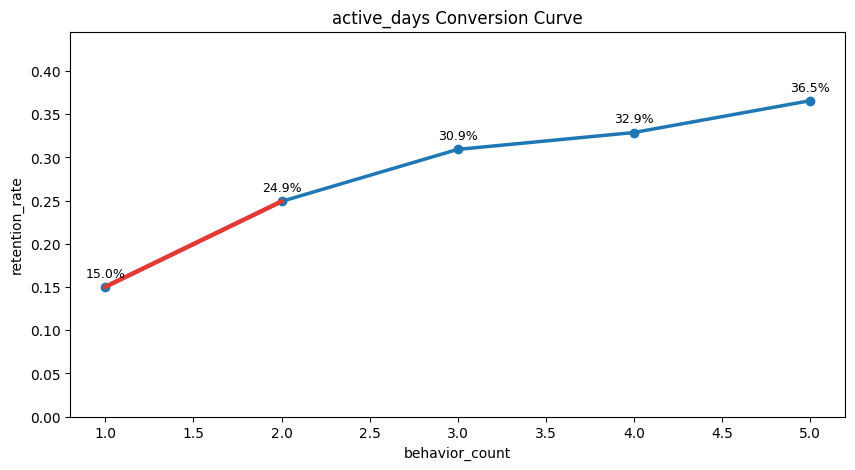

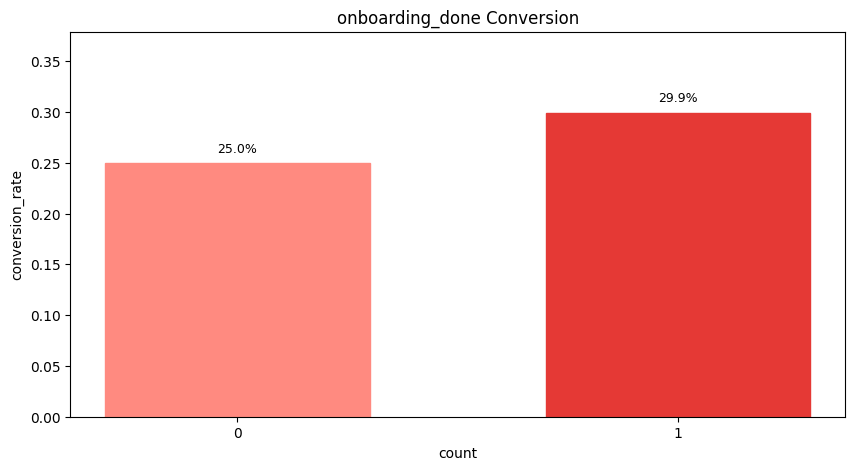

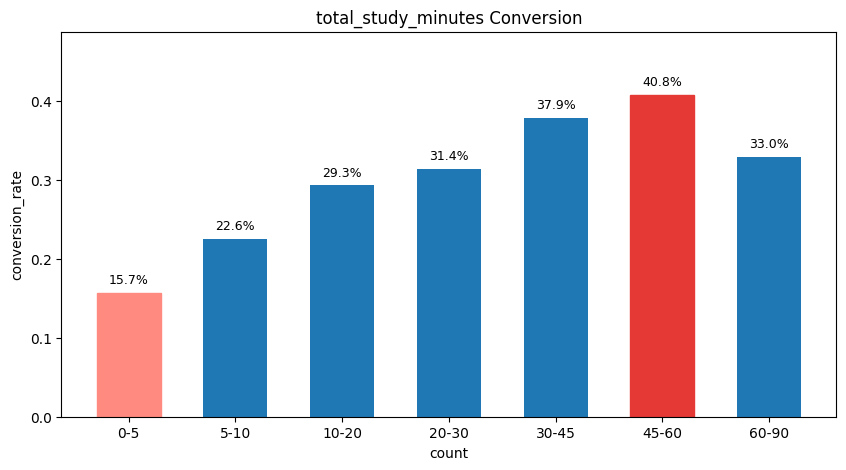

In [28]:
metrics = [
    "lesson_started",
    "lesson_completed",
    "quiz_submitted",
    "quiz_correct_count",
    "course_completed",
    "certificate_download",
    "active_days",
    "onboarding_done",
    "total_study_minutes"
]
for m in metrics:
    if m in user_behavior.columns:
        plot_conversion(user_behavior, m, mode="exact", min_users=30, q=0.95)
    else:
        print(f"[SKIP] 컬럼 없음: {m}")


### Aha moment 분석: Aha moment는 설명과 퀴즈를 통해 배운 내용이 분명하게 이해되는 순간이다.

In [29]:
df = user_behavior.copy()


In [30]:
for c in ["lesson_completed", "quiz_submitted", "converted"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

In [31]:
m_aha_main   = (df["lesson_completed"] >= 1) & (df["quiz_submitted"] >= 1)
m_ctrl_main  = (df["lesson_completed"] >= 1) & (df["quiz_submitted"] == 0)

m_aha_strong  = (df["lesson_completed"] >= 2) & (df["quiz_submitted"] >= 1)
m_ctrl_strong = (df["lesson_completed"] >= 2) & (df["quiz_submitted"] == 0)

m_ctrl_sub = (df["lesson_completed"] == 0)  # 보조 비교군

In [32]:
def summarize(mask, label):
    sub = df[mask]
    users = len(sub)
    conv_users = int(sub["converted"].sum())
    cr = conv_users / users if users > 0 else np.nan
    return {
        "group": label,
        "users": users,
        "converted_users": conv_users,
        "conversion_rate": cr
    }

In [ ]:
rows = [
    summarize(m_aha_main,   "Aha(주): lesson>=1 & quiz>=1"),
    summarize(m_ctrl_main,  "비교군(주): lesson>=1 & quiz=0"),
    summarize(m_ctrl_sub,   "비교군(보조): lesson=0"),
    summarize(m_aha_strong, "Aha(강한): lesson>=2 & quiz>=1"),
    summarize(m_ctrl_strong,"비교군(강한): lesson>=2 & quiz=0"),
]

In [34]:
result = pd.DataFrame(rows)

In [35]:
def uplift(a, b):
    return (a / b - 1) if pd.notna(a) and pd.notna(b) and b > 0 else np.nan

cr_aha_main   = result.loc[result["group"]=="Aha(주): lesson>=1 & quiz>=1", "conversion_rate"].iloc[0]
cr_ctrl_main  = result.loc[result["group"]=="비교군(주): lesson>=1 & quiz=0", "conversion_rate"].iloc[0]
cr_ctrl_sub   = result.loc[result["group"]=="비교군(보조): lesson=0", "conversion_rate"].iloc[0]
cr_aha_strong = result.loc[result["group"]=="Aha(강한): lesson>=2 & quiz>=1", "conversion_rate"].iloc[0]
cr_ctrl_strong= result.loc[result["group"]=="비교군(강한): lesson>=2 & quiz=0", "conversion_rate"].iloc[0]

In [39]:
uplift_table = pd.DataFrame([
    {"comparison": "주 비교 (Aha vs 주 비교군)", "uplift": uplift(cr_aha_main, cr_ctrl_main)},
    {"comparison": "보조 비교 (Aha vs 보조 비교군)", "uplift": uplift(cr_aha_main, cr_ctrl_sub)},
    {"comparison": "강한 검증 비교 (Aha vs 강한 비교군)", "uplift": uplift(cr_aha_strong, cr_ctrl_strong)},
])

In [40]:
display(result)
display(uplift_table)

,group,users,converted_users,conversion_rate
0,Aha(주): lesson>=1 & quiz>=1,2405,1009,0.419543
1,비교군(주): lesson>=1 & quiz=0,7829,2307,0.294674
2,비교군(보조): lesson=0,3816,604,0.158281
3,Aha(강한): lesson>=2 & quiz>=1,1810,839,0.463536
4,비교군(강한): lesson>=2 & quiz=0,3870,1174,0.303359


,comparison,uplift
0,주 비교 (Aha vs 주 비교군),0.423753
1,보조 비교 (Aha vs 보조 비교군),1.650620
2,강한 검증 비교 (Aha vs 강한 비교군),0.528010


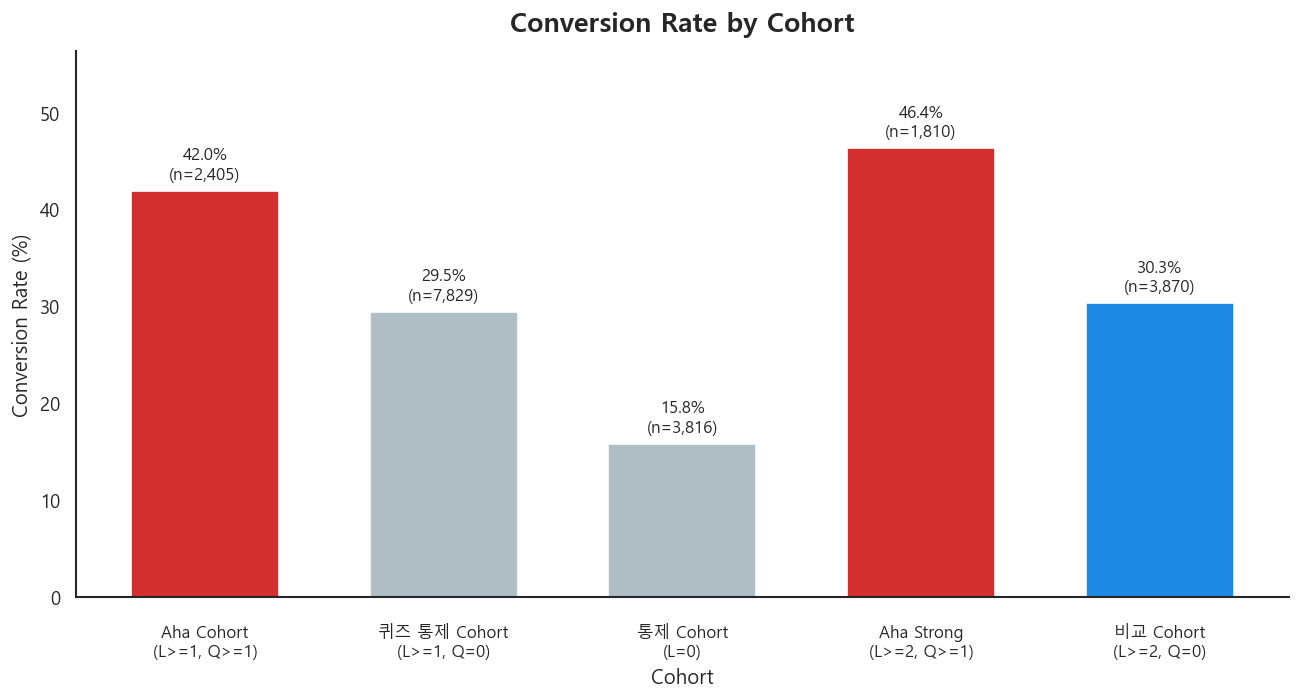

In [62]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams["axes.grid"] = False
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# -------------------------
# 1) result 만들 때 고정 ID 사용
# -------------------------
df = user_behavior.copy()
for c in ["lesson_completed", "quiz_submitted", "converted"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

def summarize(mask, group_id):
    sub = df[mask]
    users = len(sub)
    conv_users = int(sub["converted"].sum())
    cr = conv_users / users if users > 0 else np.nan
    return {"group_id": group_id, "users": users, "converted_users": conv_users, "conversion_rate": cr}

result = pd.DataFrame([
    summarize((df["lesson_completed"] >= 1) & (df["quiz_submitted"] >= 1), "aha_main"),
    summarize((df["lesson_completed"] >= 1) & (df["quiz_submitted"] == 0), "ctrl_main"),
    summarize((df["lesson_completed"] == 0),                                "ctrl_sub"),
    summarize((df["lesson_completed"] >= 2) & (df["quiz_submitted"] >= 1), "aha_strong"),
    summarize((df["lesson_completed"] >= 2) & (df["quiz_submitted"] == 0), "ctrl_strong"),
])

# -------------------------
# 2) 표시 이름/순서/색상만 별도 관리
# -------------------------
label_map = {
    "aha_main": "Aha Cohort (L>=1, Q>=1)",
    "ctrl_main": "퀴즈 통제 Cohort (L>=1, Q=0)",
    "ctrl_sub": "통제 Cohort (L=0)",
    "aha_strong": "Aha Strong (L>=2, Q>=1)",
    "ctrl_strong": "비교 Cohort (L>=2, Q=0)",
}
order_ids = ["aha_main", "ctrl_main", "ctrl_sub", "aha_strong", "ctrl_strong"]

plot_df = result.copy()
plot_df["group_label"] = plot_df["group_id"].map(label_map)

# 괄호 앞 줄바꿈 적용
plot_df["group_label"] = plot_df["group_label"].str.replace(r"\s*\(", "\n(", regex=True)

plot_df["conversion_pct"] = plot_df["conversion_rate"] * 100
plot_df["group_id"] = pd.Categorical(plot_df["group_id"], categories=order_ids, ordered=True)
plot_df = plot_df.sort_values("group_id")

# 색상 규칙: 비교 Cohort (L>=2,Q=0) 파랑
def color_of(gid):
    if gid == "ctrl_strong":
        return "#1E88E5"
    if gid.startswith("aha"):
        return "#D32F2F"
    return "#B0BEC5"

colors = [color_of(gid) for gid in plot_df["group_id"].astype(str)]

# -------------------------
# 3) 그래프
# -------------------------
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(plot_df["group_label"], plot_df["conversion_pct"], color=colors, width=0.62)

for b, v, n in zip(bars, plot_df["conversion_pct"], plot_df["users"]):
    ax.text(
        b.get_x() + b.get_width()/2, v + 0.8,
        f"{v:.1f}%\n(n={int(n):,})",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Conversion Rate by Cohort", fontsize=16, fontweight="bold", pad=12)
ax.set_xlabel("Cohort")
ax.set_ylabel("Conversion Rate (%)")
ax.set_ylim(0, plot_df["conversion_pct"].max() + 10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# X축 정렬 맞춤 (중앙)
ax.tick_params(axis="x", pad=10)
for tick in ax.get_xticklabels():
    tick.set_rotation(0)
    tick.set_horizontalalignment("center")
    tick.set_multialignment("center")
    tick.set_fontsize(10)

plt.tight_layout()
plt.show()
